# Genesis Module 1: The Weapon Balancing Problem
## Part 1: Defining the Search Space

**The Problem:** Game balance is a multi-dimensional optimization problem.
If a weapon has 3 stats (Damage, Fire Rate, Mag Size), and each stat has 100 possible values, there are $100^3 = 1,000,000$ possible combinations.
Finding the "Perfect" combination that kills an enemy in exactly 5.0 seconds is like finding a needle in a haystack.

**Objective:**
1. Define the mathematical relationship between stats and "Time-To-Kill" (TTK).
2. Visualize the "Search Space" to prove that random guessing is inefficient.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the Target
TARGET_TTK = 5.0 # We want a weapon that kills in exactly 5 seconds
ENEMY_HP = 500   # The target dummy has 500 HP

print(f"🎯 OPTIMIZATION GOAL: Create a weapon that deals {ENEMY_HP} damage in exactly {TARGET_TTK} seconds.")

🎯 OPTIMIZATION GOAL: Create a weapon that deals 500 damage in exactly 5.0 seconds.


In [3]:
# 2. The Physics Engine (The Calculator)
def calculate_ttk(damage, fire_rate, mag_size, enemy_hp):
    """
    Calculates the exact Time-To-Kill (TTK) including reload times.
    """
    # Shots needed to kill
    shots_to_kill = np.ceil(enemy_hp / damage)

    # Reload penalty (Standard 2.0s reload time)
    reloads = 0
    if shots_to_kill > mag_size:
        reloads = np.floor((shots_to_kill - 1) / mag_size)

    # Total time = Shooting Time + Reload Time
    # Note: The first shot is instant (t=0), so we subtract 1 from shooting time
    shooting_time = (shots_to_kill - 1) / fire_rate
    total_time = shooting_time + (reloads * 2.0)

    return total_time

# Test a manual guess
test_dmg = 20
test_rate = 4.0
test_mag = 30

ttk = calculate_ttk(test_dmg, test_rate, test_mag, ENEMY_HP)
print(f"🧪 TEST WEAPON ({test_dmg} dmg, {test_rate} rate): TTK = {ttk}s")

🧪 TEST WEAPON (20 dmg, 4.0 rate): TTK = 6.0s


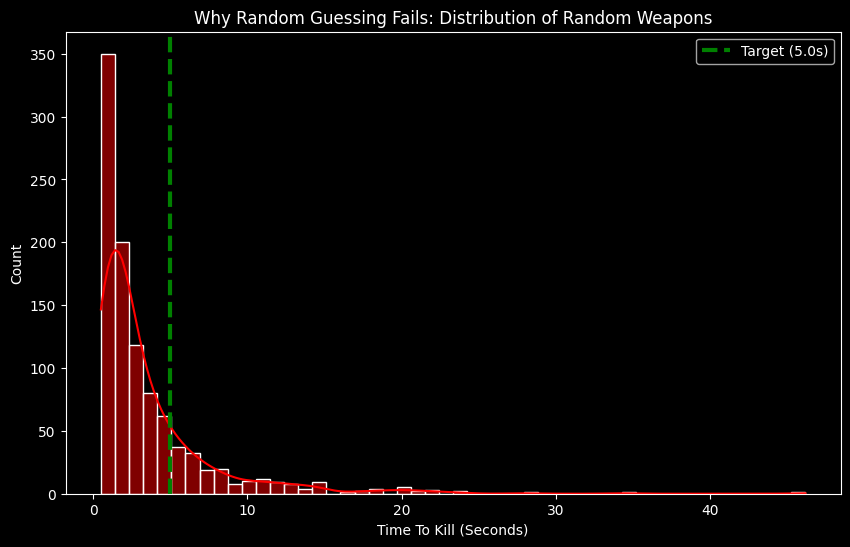

In [4]:
# 3. The "Brute Force" Attempt (Monte Carlo Simulation)
# Let's generate 1,000 random weapons and see if ANY of them are perfect.

random_weapons = []
for _ in range(1000):
    d = np.random.randint(10, 100)  # Damage
    r = np.random.uniform(1.0, 10.0) # Fire Rate
    m = np.random.randint(10, 50)   # Mag Size

    score = calculate_ttk(d, r, m, ENEMY_HP)
    random_weapons.append(score)

# Visualize the chaos
plt.figure(figsize=(10, 6))
sns.histplot(random_weapons, bins=50, kde=True, color='red')
plt.axvline(TARGET_TTK, color='green', linestyle='--', linewidth=3, label='Target (5.0s)')
plt.title("Why Random Guessing Fails: Distribution of Random Weapons")
plt.xlabel("Time To Kill (Seconds)")
plt.legend()
plt.show()